# Explore chicago_sales_modeling

Profile the assembled modeling table — **single-family Chicago sales, 2021–2025** — for shape,
dtypes, completeness, and the distribution of every major column. The 'know your data' pass
before modeling: hunting for sentinel values (a `year_built` of 0), impossible numbers, heavy
skew, and sparse columns.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

DATA_DIR = "./Data/Cook_county_data"

# Parquet preserves dtypes (category columns, string PINs) — no dtype overrides needed.
df = pd.read_parquet(f"{DATA_DIR}/chicago_sales_modeling.parquet")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# ID / key columns — identifiers, not features to profile as numeric or categorical.
# (The nearest_*_pin10 columns are 10-digit PINs; profiling them as numbers is meaningless.)
id_cols = ["pin", "pin10", "census_acs5_tract_geoid"] + [c for c in df.columns if c.endswith("_pin10")]

Shape: 56,630 rows x 82 columns
Memory: 39.1 MB


## 1. Columns & dtypes

In [5]:
pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(1),
    "example": df.iloc[0],
})

,dtype,n_unique,n_missing,pct_missing,example
pin,str,48737,0,0.0,16222220110000
year,int64,5,0,0.0,2021
township_code,int64,8,0,0.0,77
neighborhood_code,int64,187,0,0.0,77091
class,category,22,0,0.0,203
sale_date,str,1777,0,0.0,"September 03, 2021"
sale_price,int64,5499,0,0.0,75750
is_multisale,bool,1,0,0.0,False
sale_filter_same_sale_within_365,bool,1,0,0.0,False
sale_filter_less_than_10k,bool,1,0,0.0,False


## 2. First rows

In [6]:
df.head()

,pin,year,township_code,neighborhood_code,class,sale_date,sale_price,is_multisale,sale_filter_same_sale_within_365,sale_filter_less_than_10k,sale_filter_deed_type,year_built,building_sqft,land_sqft,num_bedrooms,num_rooms,num_full_baths,num_half_baths,num_fireplaces,type_of_residence,construction_quality,attic_finish,garage_size,basement_type,ext_wall_material,central_heating,repair_condition,basement_finish,single_v_multi_family,central_air,pin10,zip_code,longitude,latitude,centroid_x_crs_3435,centroid_y_crs_3435,chicago_community_area_num,flood_fema_sfha,flood_fs_factor,airport_noise_dnl,school_elementary_district_name,school_secondary_district_name,cmap_walkability_total_score,census_acs5_tract_geoid,num_pin_in_half_mile,num_bus_stop_in_half_mile,num_foreclosure_in_half_mile_past_5_years,num_foreclosure_per_1000_pin_past_5_years,num_school_in_half_mile,airport_dnl_total,nearest_bike_trail_dist_ft,nearest_cemetery_dist_ft,nearest_cta_route_dist_ft,nearest_cta_stop_dist_ft,nearest_golf_course_dist_ft,nearest_hospital_dist_ft,lake_michigan_dist_ft,nearest_major_road_dist_ft,nearest_metra_route_dist_ft,nearest_metra_stop_dist_ft,nearest_new_construction_pin10,nearest_new_construction_dist_ft,nearest_park_dist_ft,nearest_railroad_dist_ft,nearest_road_arterial_dist_ft,nearest_road_arterial_daily_traffic,nearest_road_collector_dist_ft,nearest_road_collector_daily_traffic,nearest_road_highway_dist_ft,nearest_road_highway_daily_traffic,nearest_secondary_road_dist_ft,nearest_stadium_dist_ft,nearest_university_dist_ft,nearest_vacant_land_pin10,nearest_vacant_land_dist_ft,nearest_water_dist_ft,nearest_neighbor_1_pin10,nearest_neighbor_1_dist_ft,nearest_neighbor_2_pin10,nearest_neighbor_2_dist_ft,nearest_neighbor_3_pin10,nearest_neighbor_3_dist_ft
0,16222220110000,2021,77,77091,203,"September 03, 2021",75750,False,False,False,False,1903.0,1212.0,3055.0,3.0,8.0,1.0,1.0,0.0,1.5 Story,Average,Living Area,0 cars,Full,Frame,Warm Air Furnace,Average,Formal Rec Room,Single-Family,No Central A/C,1622222011,60623.0,-87.725915,41.861705,1.149711e+06,1.892781e+06,29.0,False,1.0,52.808231,CPS ELEMENTARY - HUGHES C,CPS SECONDARY - INFINITY HS,110.0,1.703129e+10,3257.0,43.0,106.0,32.55,9.0,56.891182,11317.175353,21354.731310,2853.129750,2937.969658,NaN,5888.818320,29985.249749,1617.553283,4615.506986,8335.258451,1626101022,5001.908893,1462.127803,2460.088008,239.275482,14700.0,1042.107148,7350.0,4376.106952,14000.0,236.614902,15538.440392,15195.847901,1622222008,73.035853,6902.713322,1622222010,24.435430,1622222012,24.630775,1622222009,48.740350
1,16084210100000,2021,77,77013,210,"November 23, 2021",300000,False,False,False,False,1893.0,2112.0,4450.0,4.0,6.0,2.0,0.0,0.0,2 Story,Average,NaN,2 cars,Full,Masonry,Warm Air Furnace,Average,Unfinished,Single-Family,No Central A/C,1608421010,60644.0,-87.769338,41.881088,1.137836e+06,1.899763e+06,25.0,False,1.0,53.777637,CPS ELEMENTARY - DEPRIEST,CPS SECONDARY - AUSTIN CCA HS,109.5,1.703125e+10,1862.0,69.0,93.0,49.95,8.0,57.132904,3205.612341,12740.481552,2284.950300,2506.312629,NaN,2943.353890,40439.377140,3653.860378,2329.493497,8911.499005,1608218024,3397.010959,1258.265785,2279.225277,357.255572,14500.0,400.137942,7550.0,3609.476377,8500.0,307.708987,25747.595652,27069.912063,1608421008,62.502432,1727.407302,1608421009,25.002793,1608421028,37.510129,1608421008,62.502432
2,14334080050000,2021,74,74012,206,"April 14, 2021",2310000,False,False,False,False,1898.0,2844.0,3800.0,5.0,9.0,3.0,0.0,0.0,2 Story,Average,NaN,2 cars,Full,Masonry,Warm Air Furnace,Above Average,Formal Rec Room,Single-Family,Central A/C,1433408005,60614.0,-87.635885,41.915428,1.174077e+06,1.912544e+06,7.0,False,1.0,52.500000,CPS ELEMENTARY - LINCOLN,CPS SECONDARY - LINCOLN PARK HS,107.5,1.703107e+10,2359.0,64.0,49.0,20.77,6.0,50.000000,977.636723,14729.196946,1912.834603,2051.720991,NaN,4209.736197,2340.269498,1162.279979,7491.246113,8773.552265,1433310045,1201.391830,440.926153,1897.833805,1210.409067,23900.0,214.447478,9200.0,7681.493620

## 3. Missingness 

In [7]:
missing = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
missing[missing > 0].to_frame("pct_missing")

,pct_missing
attic_finish,80.9
nearest_golf_course_dist_ft,25.9
nearest_road_highway_daily_traffic,10.4
num_fireplaces,0.9
flood_fs_factor,0.4
zip_code,0.3
central_heating,0.2
airport_noise_dnl,0.2
num_half_baths,0.2
nearest_road_arterial_daily_traffic,0.2


## 4. Numeric columns — summary stats

In [8]:
num_cols = [c for c in df.select_dtypes(include="number").columns if c not in id_cols]
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
year,56630.0,2.022724e+03,1.394390,2.021000e+03,2.021000e+03,2.023000e+03,2.024000e+03,2.025000e+03
township_code,56630.0,7.218010e+01,2.031773,7.000000e+01,7.100000e+01,7.200000e+01,7.200000e+01,7.700000e+01
neighborhood_code,56630.0,7.236008e+04,1997.012008,7.001000e+04,7.112000e+04,7.212100e+04,7.242200e+04,7.717000e+04
sale_price,56630.0,4.223824e+05,464893.505999,1.037300e+04,1.840000e+05,3.000000e+05,4.700000e+05,1.700000e+07
year_built,56627.0,1.942003e+03,34.109385,1.844000e+03,1.918000e+03,1.944000e+03,1.959000e+03,2.025000e+03
building_sqft,56630.0,1.456431e+03,672.448566,0.000000e+00,1.028000e+03,1.240000e+03,1.700000e+03,1.553300e+04
land_sqft,56628.0,3.950656e+03,2897.895089,2.450000e+02,3.125000e+03,3.750000e+03,4.512000e+03,5.848800e+05
num_bedrooms,56625.0,3.054057e+00,0.880781,1.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00,1.200000e+01
num_rooms,56623.0,5.938223e+00,1.672614,2.000000e+00,5.000000e+00,6.000000e+00,7.000000e+00,2.800000e+01
num_full_baths,56625.0,1.454887e+00,0.759942,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,8.000000e+00


## 5. Numeric distributions — histograms

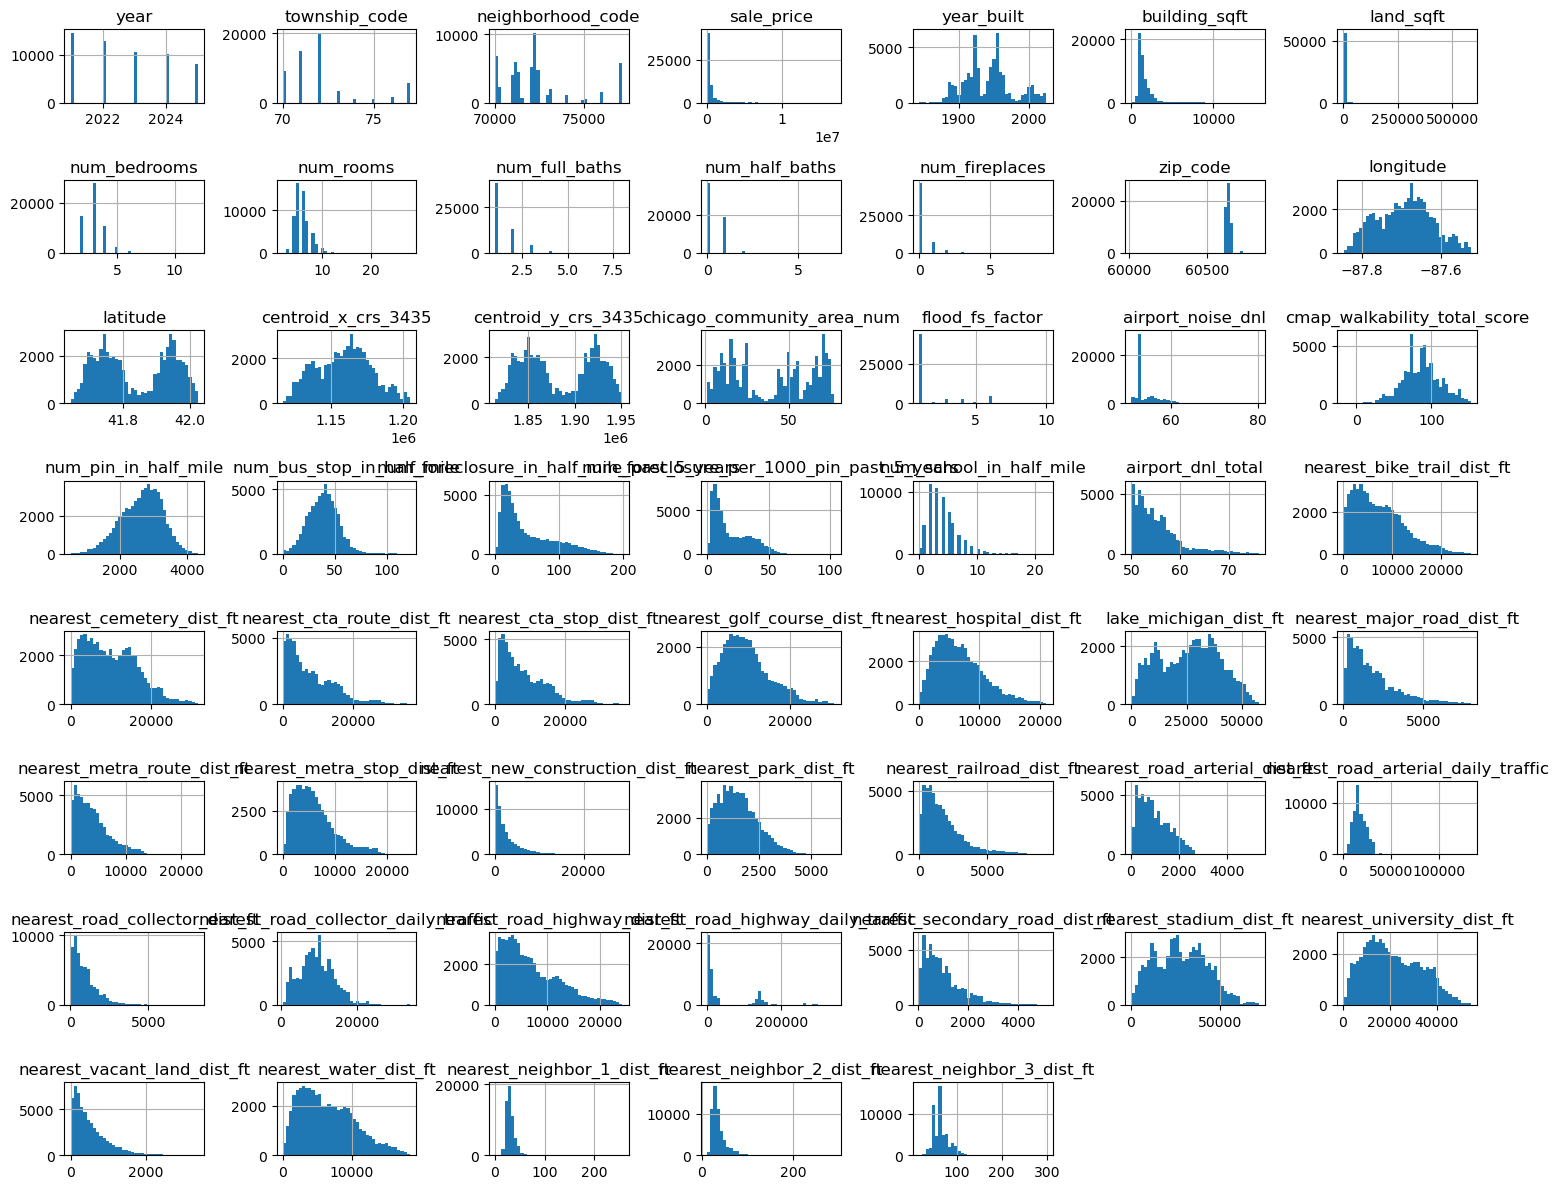

In [9]:
df[num_cols].hist(bins=40, figsize=(15, 12))
plt.tight_layout()
plt.show()

## 6. Categorical columns — value counts

In [10]:
cat_cols = [c for c in df.select_dtypes(include=["object", "category"]).columns if c not in id_cols]
for col in cat_cols:
    print(f"── {col}  ({df[col].nunique()} unique) ──")
    print(df[col].value_counts(dropna=False).head(10).to_string())
    print()

── class  (22 unique) ──
class
203    23200
202    10217
205     7192
295     3587
278     3236
206     2239
210     1809
204     1652
234     1580
207     1200

── sale_date  (1777 unique) ──
sale_date
May 31, 2022          97
June 01, 2021         91
June 30, 2021         89
October 29, 2021      87
November 30, 2021     87
September 20, 2021    87
November 29, 2021     86
May 28, 2021          85
May 27, 2022          85
May 12, 2021          84

── type_of_residence  (5 unique) ──
type_of_residence
1 Story        26815
2 Story        16328
1.5 Story       8728
3 Story +       3180
Split Level     1579

── construction_quality  (3 unique) ──
construction_quality
Average    56214
Deluxe       380
Poor          36

── attic_finish  (2 unique) ──
attic_finish
NaN            45830
Living Area    10797
Partial            3

── garage_size  (8 unique) ──
garage_size
2 cars      29470
0 cars      11896
1 cars       9534
1.5 cars     3577
2.5 cars     1527
3 cars        538
4 cars         4

C:\Users\dabhi\AppData\Local\Temp\ipykernel_39792\1099120017.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = [c for c in df.select_dtypes(include=["object", "category"]).columns if c not in id_cols]


## 7. Target: sale_price


count        56,630
mean        422,382
std         464,894
min          10,373
25%         184,000
50%         300,000
75%         470,000
max      17,000,000
Name: sale_price, dtype: str


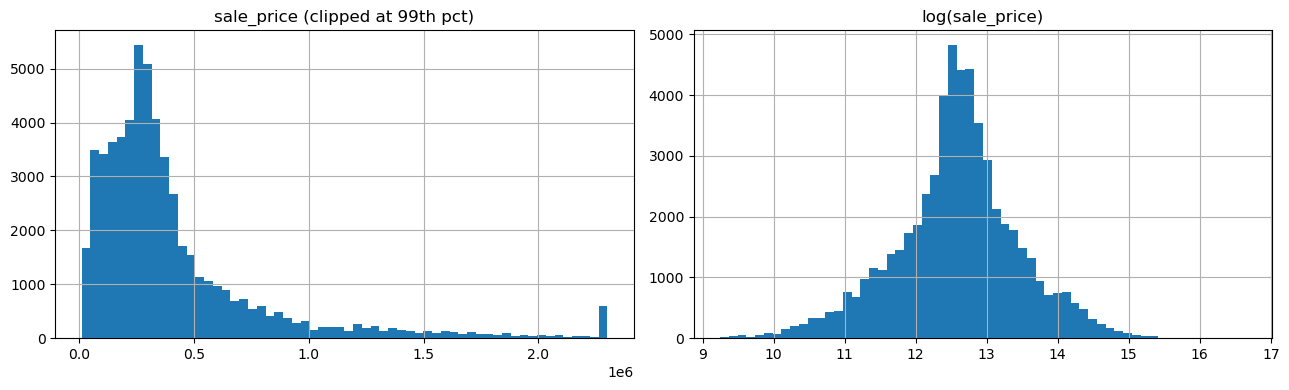

In [14]:
print(df["sale_price"].describe().apply(lambda x: f"{x:,.0f}"))


fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df["sale_price"].clip(upper=df["sale_price"].quantile(0.99)).hist(bins=60, ax=ax[0])
ax[0].set_title("sale_price (clipped at 99th pct)")
np.log(df["sale_price"]).hist(bins=60, ax=ax[1])
ax[1].set_title("log(sale_price)")
plt.tight_layout(); plt.show()

## 8. Coverage over time

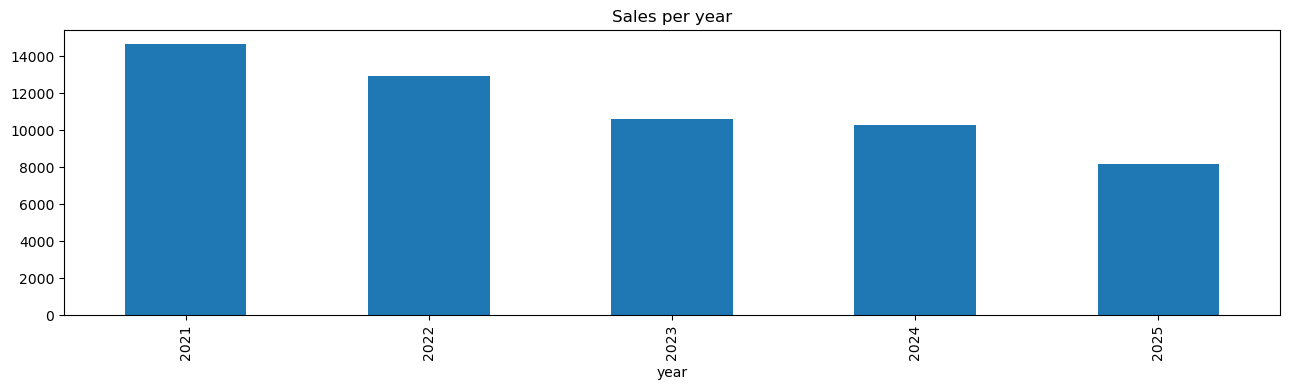

,count
year,
2021,14655
2022,12928
2023,10606
2024,10294
2025,8147


In [12]:
by_year = df.groupby("year").size()
by_year.plot(kind="bar", figsize=(13, 4), title="Sales per year")
plt.tight_layout(); plt.show()
by_year.to_frame("count")

## 9. Spatial coverage

Scatter of lat/lon — should trace the shape of Chicago. Stray points far outside the
cluster are geocoding errors worth filtering.

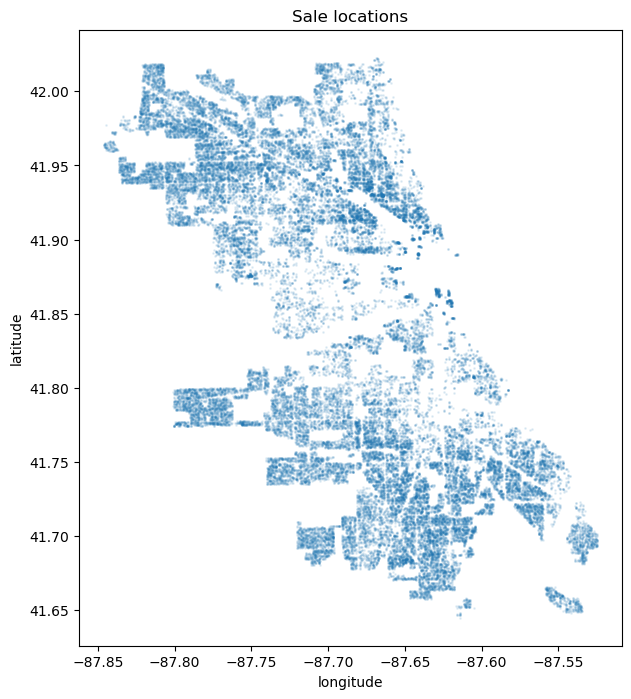

In [15]:

df.plot.scatter(x="longitude", y="latitude", s=1, alpha=0.1, figsize=(7, 8))
plt.title("Sale locations"); plt.show()